### Objective

The goal of this explore and clean historical retail sales data.

### Dataset

The dataset contains daily observations across multiple stores, products and regions.

The main forecasting target is `Demand`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
df = pd.read_csv("./Data/sales_data.csv")
print("Shape:", df.shape)

display(df.head())

Shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']

Data types:


Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [5]:
print("Number of unique dates:", df["Date"].nunique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Number of unique dates: 760
Date range: 2022-01-01 to 2024-01-30


# Converting date column in datetime format

In [6]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].dtype)

datetime64[ns]


 # Missing values

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing)

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

# Check duplicates

In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


# Check for bad numeric values

In [11]:
numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Demand"
]

for col in numeric_columns:
    print(
        f"{col:25} "
        f"min={df[col].min():8.2f} "
        f"max={df[col].max():8.2f} "
        f"negative={(df[col] < 0).sum()}"
    )

Inventory Level           min=    0.00 max= 2267.00 negative=0
Units Sold                min=    0.00 max=  426.00 negative=0
Units Ordered             min=    0.00 max= 1616.00 negative=0
Price                     min=    4.74 max=  228.03 negative=0
Discount                  min=    0.00 max=   25.00 negative=0
Promotion                 min=    0.00 max=    1.00 negative=0
Competitor Pricing        min=    4.29 max=  261.22 negative=0
Epidemic                  min=    0.00 max=    1.00 negative=0
Demand                    min=    4.00 max=  430.00 negative=0


In [12]:
coverage = (
    df.groupby(["Store ID", "Product ID"])["Date"]
      .nunique()
)

print("Minimum dates per Store/Product:", coverage.min())
print("Maximum dates per Store/Product:", coverage.max())
print("Expected dates:", df["Date"].nunique())

Minimum dates per Store/Product: 760
Maximum dates per Store/Product: 760
Expected dates: 760


### Observation

The dataset forms a complete daily panel: every Store/Product combination has observations for all 760 dates. This is useful for creating lag and rolling demand features without dealing with missing dates within individual product series.

# Understand the dataset

In [13]:
print("Number of stores:", df["Store ID"].nunique())
print("Number of products:", df["Product ID"].nunique())
print("Number of categories:", df["Category"].nunique())
print("Number of regions:", df["Region"].nunique())

print("\nStores:")
print(df["Store ID"].unique())

print("\nCategories:")
print(df["Category"].unique())

print("\nRegions:")
print(df["Region"].unique())

Number of stores: 5
Number of products: 20
Number of categories: 5
Number of regions: 4

Stores:
['S001' 'S002' 'S003' 'S004' 'S005']

Categories:
['Electronics' 'Clothing' 'Groceries' 'Toys' 'Furniture']

Regions:
['North' 'South' 'East' 'West']


In [16]:
display(df.describe())

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000,"76,000.00","76,000.00","76,000.00","76,000.00","76,000.00","76,000.00","76,000.00","76,000.00","76,000.00"
mean,2023-01-15 12:00:00,301.06,88.83,89.09,67.73,9.09,0.33,69.45,0.20,104.32
min,2022-01-01 00:00:00,0.00,0.00,0.00,4.74,0.00,0.00,4.29,0.00,4.00
25%,2022-07-09 18:00:00,136.00,58.00,0.00,32.00,5.00,0.00,32.62,0.00,71.00
50%,2023-01-15 12:00:00,227.00,84.00,0.00,64.50,10.00,0.00,65.70,0.00,100.00
75%,2023-07-24 06:00:00,408.00,114.00,121.00,95.83,10.00,1.00,97.93,0.00,133.00
max,2024-01-30 00:00:00,"2,267.00",426.00,"1,616.00",228.03,25.00,1.00,261.22,1.00,430.00
std,NaN,226.51,43.99,162.40,39.38,7.48,0.47,40.94,0.40,46.96


# Feature engineering from date

In [17]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["day_of_week"] = df["Date"].dt.dayofweek
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

display(df.head())

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,year,month,day,day_of_week,week_of_year,is_weekend,dow_sin,dow_cos,month_sin,month_cos
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,5,52,1,-0.97,-0.22,0.50,0.87
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,5,52,1,-0.97,-0.22,0.50,0.87
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,5,52,1,-0.97,-0.22,0.50,0.87
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,5,52,1,-0.97,-0.22,0.50,0.87
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,5,52,1,-0.97,-0.22,0.50,0.87


# EDA Charts

# Demand over time

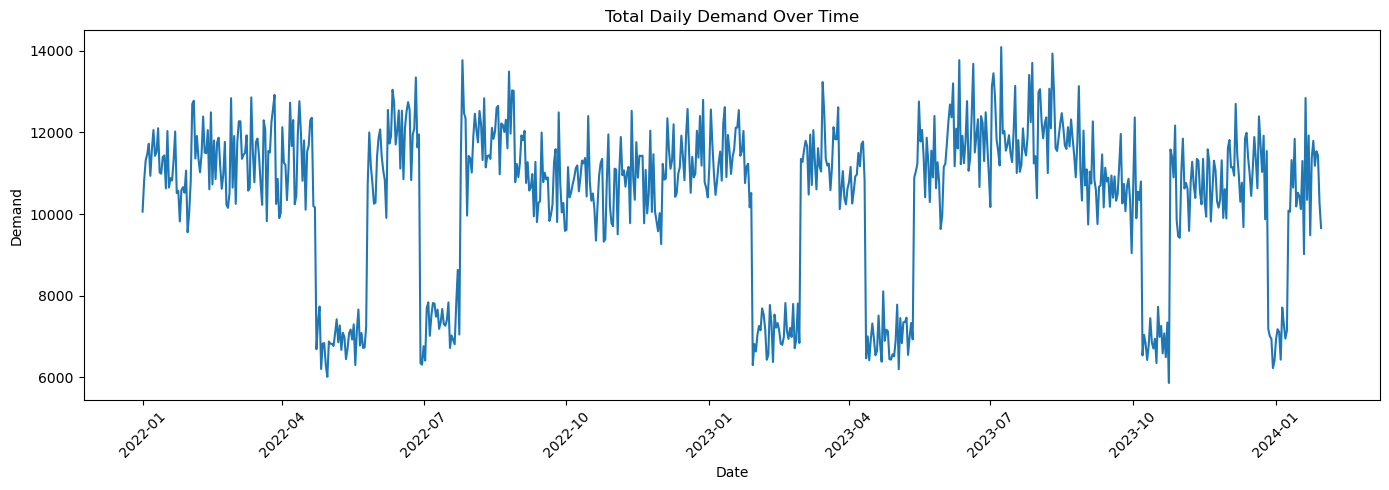

In [18]:
daily_demand = (
    df.groupby("Date")["Demand"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand"]
)

plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Demand by product

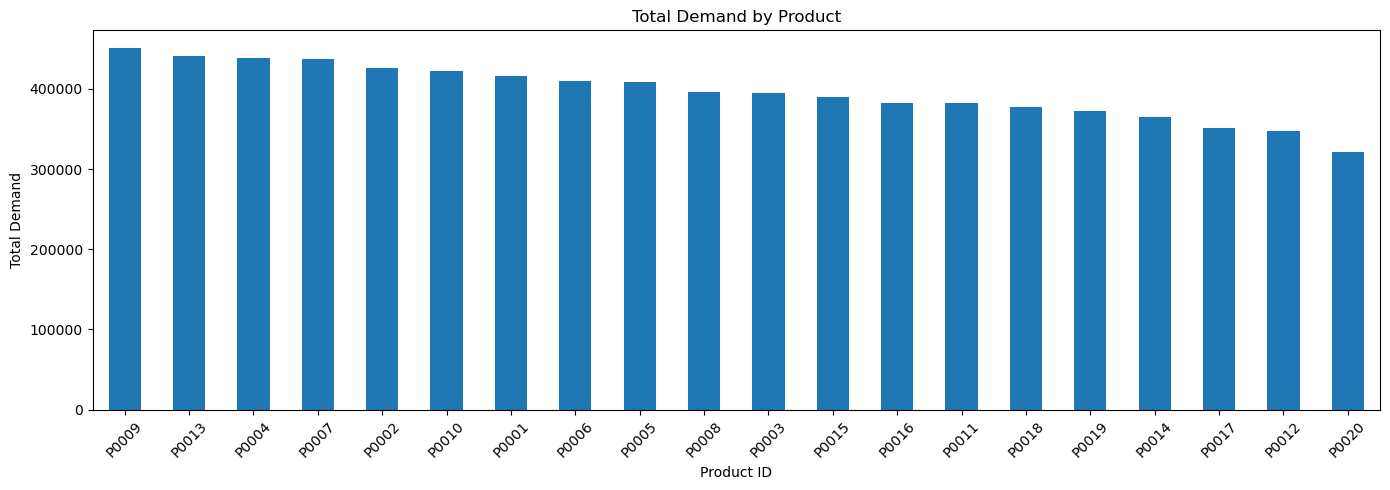

In [19]:
product_demand = (
    df.groupby("Product ID")["Demand"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14, 5))

product_demand.plot(kind="bar")

plt.title("Total Demand by Product")
plt.xlabel("Product ID")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Demand by region

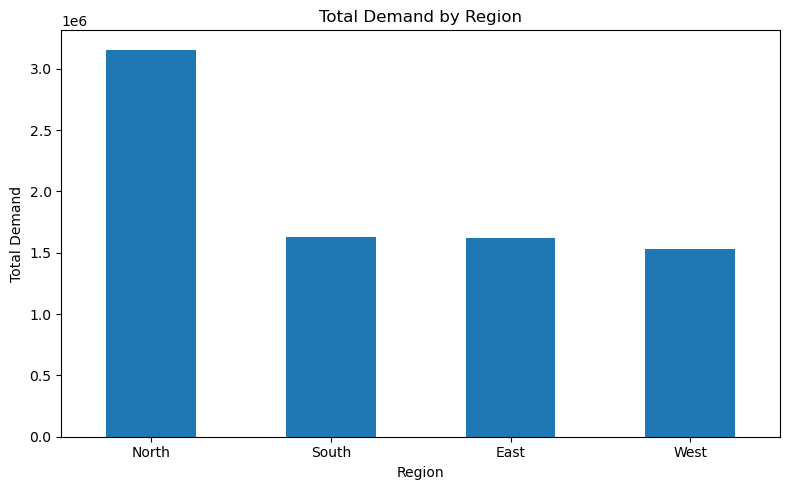

In [20]:
region_demand = (
    df.groupby("Region")["Demand"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

region_demand.plot(kind="bar")

plt.title("Total Demand by Region")
plt.xlabel("Region")
plt.ylabel("Total Demand")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Demand by day of week

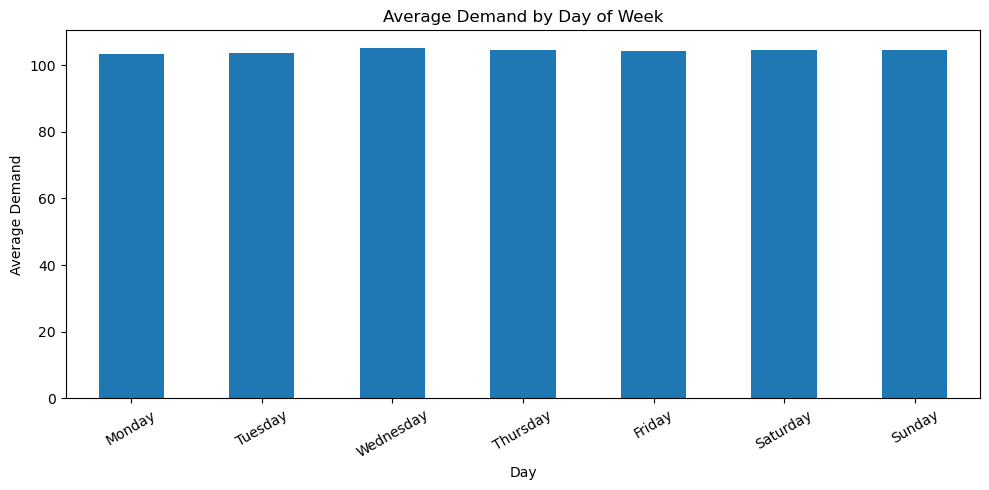

In [21]:
dow_demand = (
    df.groupby("day_of_week")["Demand"]
      .mean()
)

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_demand.index = [day_names[i] for i in dow_demand.index]

plt.figure(figsize=(10, 5))

dow_demand.plot(kind="bar")

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
df.to_csv('processed_csv_dataset.csv')